In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, losses, Model
from random import randint

In [5]:
data = pd.read_csv(r"D:\ANN and DL\GestureDataset_110x110x3.csv", header=None)

# First column = labels, rest are pixel values
labels = data.iloc[:, 0].values
pixels = data.iloc[:, 1:].values

# Filter only category 0
pixels_0 = pixels[labels == 0]

# Convert to float32 and reshape to (110,110,3)
x_data = np.array(pixels_0, dtype=np.float32).reshape(-1, 110, 110, 3)

# Split into train/test
from sklearn.model_selection import train_test_split
x_train, x_test = train_test_split(x_data, test_size=0.2, random_state=42)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (800, 110, 110, 3)
Testing shape: (200, 110, 110, 3)


In [6]:
input_layer = layers.Input(shape=x_train.shape[1:])  # (110,110,3)
flattened = layers.Flatten()(input_layer)
hidden = layers.Dense(100, activation='relu')(flattened)
latent = layers.Dense(20, activation='relu')(hidden)

encoder = Model(inputs=input_layer, outputs=latent, name='encoder')
encoder.summary()


Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 110, 110, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 36300)             0         
                                                                 
 dense (Dense)               (None, 100)               3630100   
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
Total params: 3632120 (13.86 MB)
Trainable params: 3632120 (13.86 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
input_layer_decoder = layers.Input(shape=encoder.output.shape[1:])  # (20,)
upsampled = layers.Dense(100, activation='relu')(input_layer_decoder)
upsampled2 = layers.Dense(110 * 110 * 3, activation='sigmoid')(upsampled)
constructed = layers.Reshape(x_train.shape[1:])(upsampled2)

decoder = Model(inputs=input_layer_decoder, outputs=constructed, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 20)]              0         
                                                                 
 dense_2 (Dense)             (None, 100)               2100      
                                                                 
 dense_3 (Dense)             (None, 36300)             3666300   
                                                                 
 reshape (Reshape)           (None, 110, 110, 3)       0         
                                                                 
Total params: 3668400 (13.99 MB)
Trainable params: 3668400 (13.99 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
autoencoder = Model(inputs=encoder.input, outputs=decoder(encoder.output))
autoencoder.compile(
    optimizer='adam',
    loss=losses.MeanSquaredError(),
    metrics=['accuracy']
)
autoencoder.summary()

summary = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=16,
    validation_data=(x_test, x_test)
)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 110, 110, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 36300)             0         
                                                                 
 dense (Dense)               (None, 100)               3630100   
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
 decoder (Functional)        (None, 110, 110, 3)       3668400   
                                                                 
Total params: 7300520 (27.85 MB)
Trainable params: 7300520 (27.85 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20


50/50 [

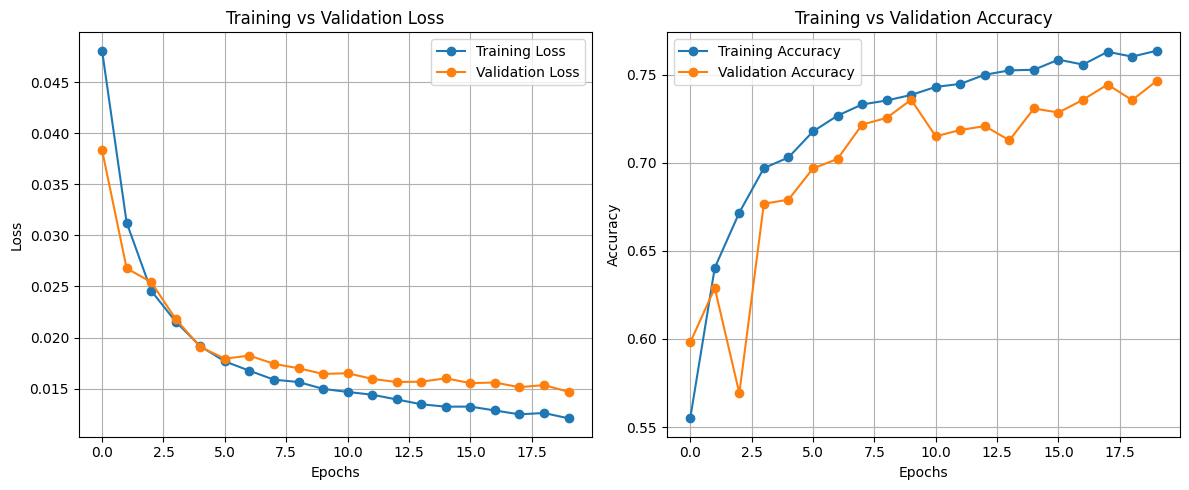

In [9]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(summary.history['loss'], label='Training Loss', marker='o')
plt.plot(summary.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(summary.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(summary.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

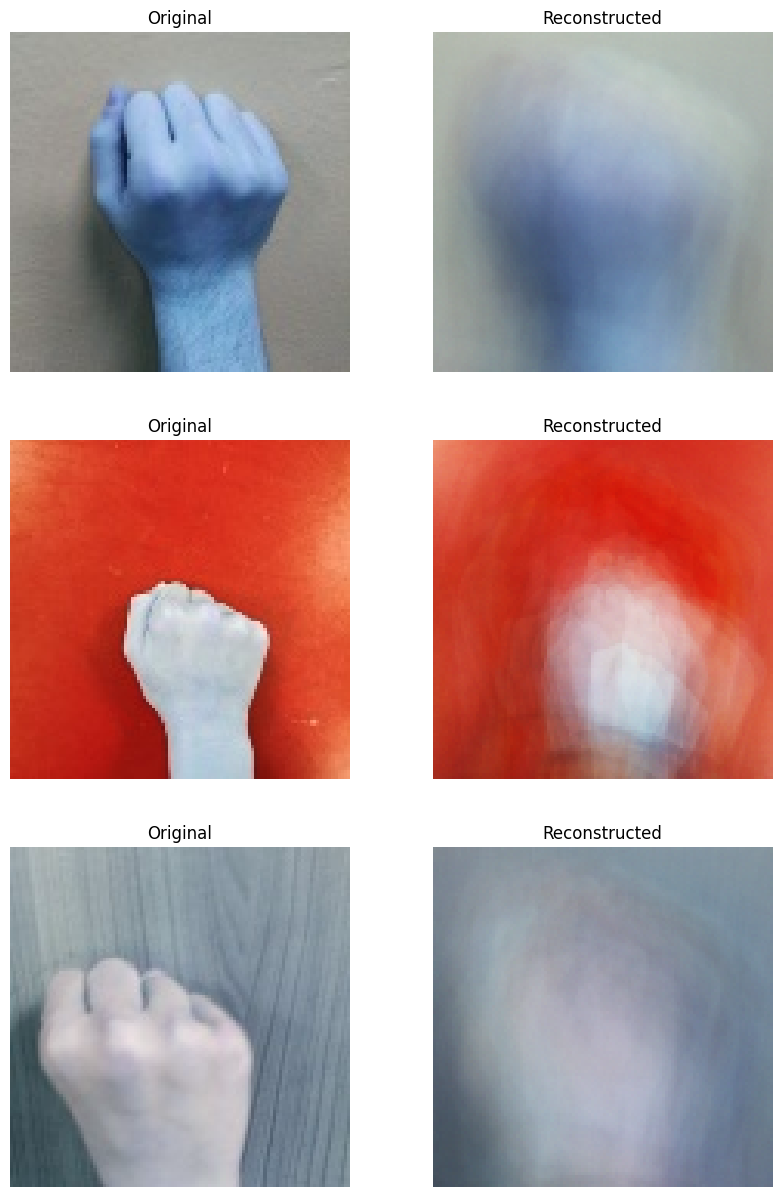

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(10, 15))
for i in range(3):
    sample = x_train[randint(0, x_train.shape[0])]
    axs[i][0].imshow(sample)
    axs[i][0].set_title("Original")
    axs[i][0].axis("off")

    reconstructed = autoencoder(np.expand_dims(sample, 0))[0]
    axs[i][1].imshow(reconstructed)
    axs[i][1].set_title("Reconstructed")
    axs[i][1].axis("off")

plt.show()